In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Assuming 'loan_data_new.csv' is directly in your Google Drive's root or a known folder.
# Adjust the path below if your file is in a subfolder, e.g., '/content/drive/My Drive/my_folder/loan_data_new.csv'
path = "/content/drive/My Drive/loan_data_new.csv"
df = pd.read_csv(path)

# Show the first 5 rows to confirm it works
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
# 1. Missing/Null Filter
print("Null values before:", df.isnull().sum().sum())
df = df.dropna()

# 2. Duplicate Sample Remove
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Data Type Correction
# This shows you the types; usually CSVs load correctly, but it's good to check
print(df.dtypes)

# Confirming the new size
print("Cleaned data shape:", df.shape)

Null values before: 0
Duplicates before: 0
Age                      int64
Gender                  object
Education               object
Person Income            int64
Employee Experience      int64
Home Onwership          object
Loan Amount              int64
Loan Intent             object
Loan interest Rate     float64
Loan percentage        float64
Credit History           int64
Credit Score             int64
Previous Loan           object
Loan Status              int64
dtype: object
Cleaned data shape: (45000, 14)


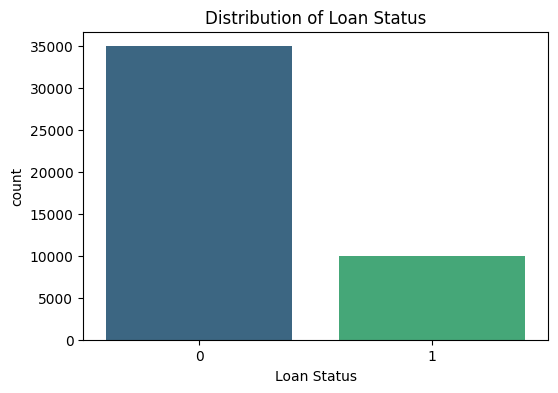

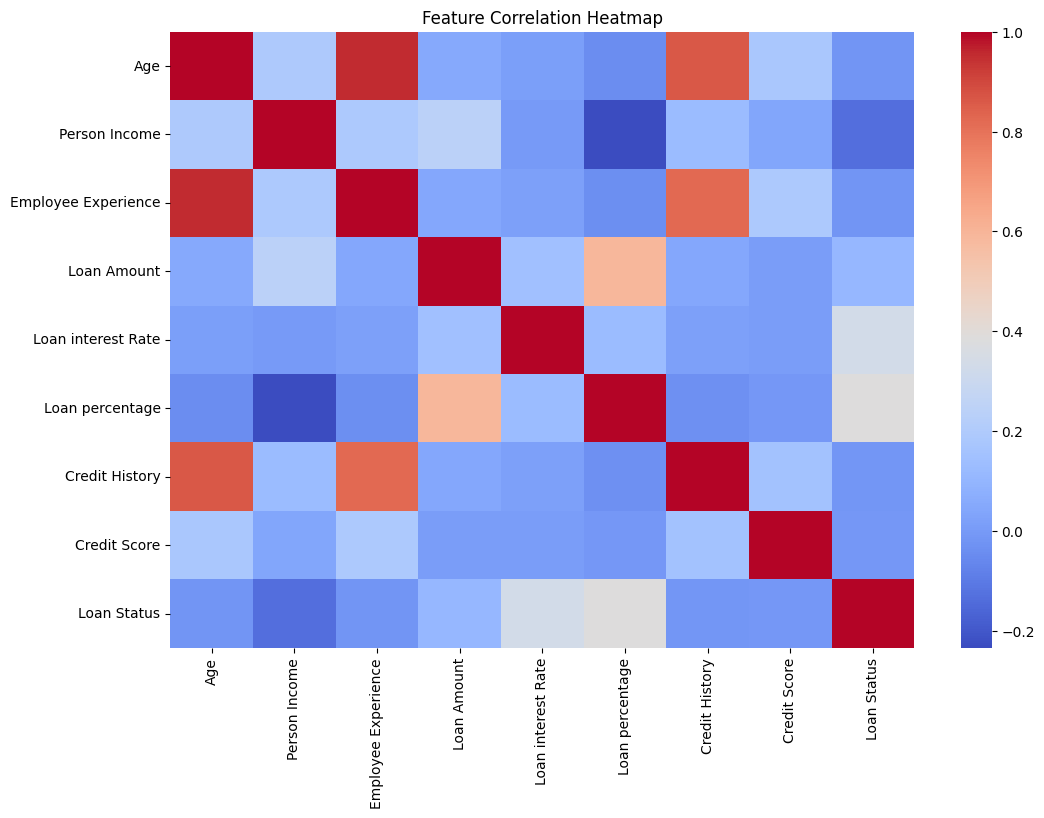

In [ ]:
#Step 3: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target Distribution (Loan Status)
plt.figure(figsize=(6,4))
sns.countplot(x='Loan Status', data=df, palette='viridis', hue='Loan Status', legend=False) # Fix FutureWarning
plt.title('Distribution of Loan Status')
plt.show()

# 2. Correlation Heatmap (To see which features matter)
# Drop non-numeric (object) columns for correlation calculation
non_numeric_cols = df.select_dtypes(include='object').columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=non_numeric_cols).corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
#Step 4: Outlier Removal
# Removing extreme outliers (e.g., from 'Loan Amount')
# You can change 'Loan Amount' to any other numeric column you wish to remove outliers from.
limit = df['Loan Amount'].quantile(0.99)
df = df[df['Loan Amount'] < limit]

print(f"New data shape after outlier removal: {df.shape}")

New data shape after outlier removal: (44550, 14)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

path = "/content/drive/My Drive/loan_data_new.csv"

# Load the original data (ensure we start with fresh categorical columns)
temp_df = pd.read_csv(path)

# Apply previous cleaning and outlier removal steps to temp_df
temp_df = temp_df.dropna()
temp_df = temp_df.drop_duplicates()
limit = temp_df['Loan Amount'].quantile(0.99)
temp_df = temp_df[temp_df['Loan Amount'] < limit]

# Hardcode the categorical columns to ensure they are always identified for encoding
# Based on df.dtypes output, these are the categorical columns:
categorical_cols_to_encode = ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']

label_encoders = {}
for col in categorical_cols_to_encode:
    if col in temp_df.columns: # Check if column exists, for robustness
        le = LabelEncoder()
        # Convert to lowercase before fitting the encoder for consistency
        temp_df[col] = temp_df[col].astype(str).str.lower()
        temp_df[col] = le.fit_transform(temp_df[col])
        label_encoders[col] = le

print("Encoding complete. Categorical columns in 'temp_df' are now numeric.")

# Save the dictionary of fitted label encoders
save_dir = '/content/drive/MyDrive/PED_Project/'
joblib.dump(label_encoders, save_dir + 'loan_prediction_label_encoders_dict.pkl')
print(f"Label encoders dictionary saved to {save_dir}loan_prediction_label_encoders_dict.pkl")

# Update the global 'df' to the encoded version for subsequent steps in the notebook
df = temp_df.copy() # Ensure global df is updated with encoded data for model training etc.

print("Updated global 'df' with encoded values.")
df.head()

Encoding complete. Categorical columns in 'temp_df' are now numeric.
Label encoders dictionary saved to /content/drive/MyDrive/PED_Project/loan_prediction_label_encoders_dict.pkl
Updated global 'df' with encoded values.


,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
5,21,0,3,12951,0,2,2500,5,7.14,0.19,2,532,0,1
9,21,0,3,12739,0,2,1600,5,14.74,0.13,3,640,0,1
11,21,0,0,13113,0,2,4500,2,8.63,0.34,2,651,0,1


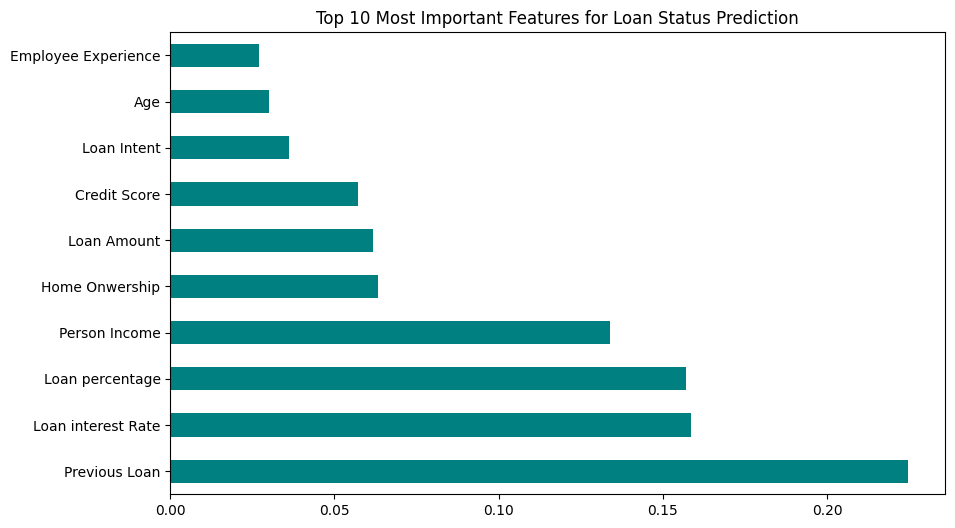

In [ ]:
#Step 6: Feature Importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Separate Features (X) and Target (y)
# The target column is 'Loan Status', not 'label'.
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

# Fit a quick model to get importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

# Plotting
feat_importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features for Loan Status Prediction')
plt.show()

In [ ]:
#Step 7: Model Feed (The 2 Models)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# 1. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the data for Logistic Regression (important for convergence)
scaler = StandardScaler() # Initialize scaler
X_train_scaled = scaler.fit_transform(X_train) # Fit on training data and transform
X_test_scaled = scaler.transform(X_test) # Transform test data using the fitted scaler

# 3. Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000) # Keep max_iter, but scaling should help
lr_model.fit(X_train_scaled, y_train) # Train with scaled data
lr_pred = lr_model.predict(X_test_scaled) # Predict with scaled data

# 4. Model 2: Random Forest (doesn't typically require scaling, but good to have a consistent dataset)
# For consistency, we can also use scaled data here, or keep it unscaled as RF is less sensitive.
# For this fix, I'll keep RF on unscaled data as it was not having convergence issues.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


In [ ]:
#Step 8: Save the Model
import pickle
import joblib # Ensure joblib is imported if not already, for consistency

# Define the directory for saving models
save_dir = '/content/drive/MyDrive/PED_Project/'

# Save the trained Random Forest model to your Drive with a descriptive name
with open(save_dir + 'loan_prediction_rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# The dictionary of label encoders is now saved in the encoding step (Step 5)
# using joblib for better handling of multiple encoders.
# This simplifies model saving as 'le' (single encoder) is no longer directly used here.

print(f"Random Forest Model saved to {save_dir}loan_prediction_rf_model.pkl")
print(f"Label encoders dictionary saved in the encoding step to {save_dir}loan_prediction_label_encoders_dict.pkl")

Random Forest Model saved to /content/drive/MyDrive/PED_Project/loan_prediction_rf_model.pkl
Label encoders dictionary saved in the encoding step to /content/drive/MyDrive/PED_Project/loan_prediction_label_encoders_dict.pkl


In [ ]:
import pickle
import joblib # Import joblib for loading the dictionary of encoders
import pandas as pd # Ensure pandas is imported for creating sample DataFrame
import numpy as np # Ensure numpy is imported for creating sample array

save_dir = '/content/drive/MyDrive/PED_Project/'

# Load the trained Random Forest model
with open(save_dir + 'loan_prediction_rf_model.pkl', 'rb') as f:
    loaded_rf_model = pickle.load(f)
print(f"Random Forest Model loaded from {save_dir}loan_prediction_rf_model.pkl")

# Load the dictionary of label encoders
loaded_label_encoders = joblib.load(save_dir + 'loan_prediction_label_encoders_dict.pkl')
print(f"Label Encoders Dictionary loaded from {save_dir}loan_prediction_label_encoders_dict.pkl")

# --- Example of using the loaded model and encoders for prediction on new, raw data ---
print("\n--- Testing Loaded Model with New Raw Data ---")

# Define a sample of new raw loan application data
# Ensure this matches the columns of X *before* encoding, with original string values for categorical features
new_raw_loan_data = {
    'Age': [35],
    'Gender': ['Male'],
    'Education': ['Master'],
    'Person Income': [70000],
    'Employee Experience': [10],
    'Home Onwership': ['RENT'],
    'Loan Amount': [15000],
    'Loan Intent': ['MEDICAL'],
    'Loan interest Rate': [10.0],
    'Loan percentage': [0.15],
    'Credit History': [5],
    'Credit Score': [720],
    'Previous Loan': ['No']
}
new_loan_df = pd.DataFrame(new_raw_loan_data)

# Preprocess the new raw data using the loaded label encoders
categorical_cols_to_encode = list(loaded_label_encoders.keys())

for col in categorical_cols_to_encode:
    if col in new_loan_df.columns:
        # Convert to lowercase if it's a string column to match training data casing
        if new_loan_df[col].dtype == 'object':
            new_loan_df[col] = new_loan_df[col].str.lower()

        le = loaded_label_encoders[col]
        # Identify values in new_loan_df that are not in the encoder's classes
        # This creates a boolean mask where True indicates an unseen label
        unseen_labels_mask = ~new_loan_df[col].isin(le.classes_)

        if unseen_labels_mask.any():
            # Get the actual unseen label(s) for logging
            unseen_actual_labels = new_loan_df.loc[unseen_labels_mask, col].unique().tolist()

            # --- Handling unseen labels ---
            # For LabelEncoder, the standard behavior is to error on unseen labels during transform.
            # To avoid error and allow prediction, we can replace unseen labels with a known value.
            # A common approach is to map them to the most frequent class, or a specific 'unknown' class.
            # Here, as a pragmatic solution to proceed, we will replace with the first class the encoder knows.
            # This is a simplification; in a production system, you'd want a more robust strategy
            # (e.g., adding an 'unknown' category during training, or imputation).

            if len(le.classes_) > 0:
                # Use the first class in the encoder as a fallback.
                default_known_class = le.classes_[0]
                new_loan_df.loc[unseen_labels_mask, col] = default_known_class
                print(f"Warning: Column '{col}' contains previously unseen label(s) {unseen_actual_labels}. Replacing with '{default_known_class}' for prediction.")
            else:
                # This case implies an empty encoder, which is an error in itself.
                raise ValueError(f"LabelEncoder for column '{col}' has no classes defined, cannot transform.")

        # Now transform the column, which should only contain known labels (original or replaced)
        new_loan_df[col] = le.transform(new_loan_df[col])

# Now make a prediction using the loaded Random Forest model
new_prediction = loaded_rf_model.predict(new_loan_df)

# Interpret and display the prediction
if new_prediction[0] == 1:
    print("🚨 ALERT: This new loan application is classified as LIKELY TO DEFAULT!")
else:
    print("✅ SAFE: This new loan application is classified as LIKELY TO BE REPAID.")

Random Forest Model loaded from /content/drive/MyDrive/PED_Project/loan_prediction_rf_model.pkl
Label Encoders Dictionary loaded from /content/drive/MyDrive/PED_Project/loan_prediction_label_encoders_dict.pkl

--- Testing Loaded Model with New Raw Data ---
✅ SAFE: This new loan application is classified as LIKELY TO BE REPAID.



--- Performance Analysis: Logistic Regression ---
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6897
           1       0.76      0.73      0.74      2013

    accuracy                           0.89      8910
   macro avg       0.84      0.83      0.83      8910
weighted avg       0.88      0.89      0.89      8910



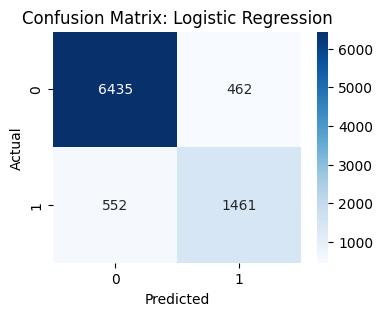


--- Performance Analysis: Random Forest ---
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6897
           1       0.88      0.76      0.81      2013

    accuracy                           0.92      8910
   macro avg       0.91      0.86      0.88      8910
weighted avg       0.92      0.92      0.92      8910



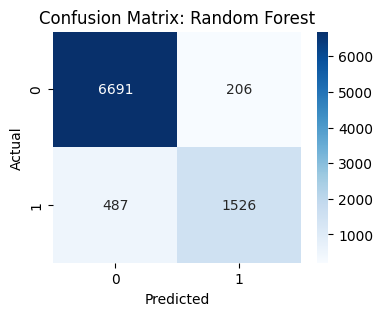

In [ ]:
#Step 8: Matrices (Performance Analysis)
# Function to show results clearly
def show_results(name, y_test, y_pred):
    print(f"\n--- Performance Analysis: {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    # Plotting Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# Run for both models
show_results("Logistic Regression", y_test, lr_pred)
show_results("Random Forest", y_test, rf_pred)

In [ ]:
import numpy as np
import pandas as pd # Import pandas to create a DataFrame for prediction

# The rf_model was trained on the following 13 features:
# X.columns: Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
#        'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
#        'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan'],
#       dtype='object')

# 1. Create a fake "New Loan Application" to test
# This sample must have 13 features, matching the training data (X_train or X).
# The values should also correspond to the encoded values for categorical features.
# Example values (replace with meaningful data for a specific loan application):
# Age: 30
# Gender: 1 (e.g., female, if 0 was male and 1 was female after encoding)
# Education: 0 (e.g., Bachelor, if 0 was Bachelor after encoding)
# Person Income: 50000
# Employee Experience: 5
# Home Onwership: 2 (e.g., RENT)
# Loan Amount: 10000
# Loan Intent: 0 (e.g., Debt Consolidation)
# Loan interest Rate: 12.5
# Loan percentage: 0.2
# Credit History: 3
# Credit Score: 700
# Previous Loan: 0 (e.g., No)

sample_data_values = np.array([[
    30,  # Age
    1,   # Gender (encoded)
    0,   # Education (encoded)
    50000, # Person Income
    5,   # Employee Experience
    2,   # Home Onwership (encoded)
    10000, # Loan Amount
    0,   # Loan Intent (encoded)
    12.5, # Loan interest Rate
    0.2, # Loan percentage
    3,   # Credit History
    700, # Credit Score
    0    # Previous Loan (encoded)
]])

# It's good practice to pass data as a DataFrame with feature names for clarity and robustness
# Use the actual column names from X (or X_train) that the model was fitted with
feature_names = X.columns.tolist()
sample_df = pd.DataFrame(sample_data_values, columns=feature_names)

# 2. Ask the model to predict
prediction = rf_model.predict(sample_df)

# 3. Show the result
if prediction[0] == 1:
    print("🚨 ALERT: This loan application is classified as LIKELY TO DEFAULT!")
else:
    print("✅ SAFE: This loan application is classified as LIKELY TO BE REPAID.")

✅ SAFE: This loan application is classified as LIKELY TO BE REPAID.
